# Intervention Effectiveness Analyzer
## HavenBridge ML Pipeline 5

### Problem Framing

**Business Question:** Which interventions actually improve resident outcomes, and what factors make a counseling session most effective?

HavenBridge needs to know which interventions are working so limited staff time and resources can be focused on what actually helps residents recover. This is an **explanatory** model — we want to understand the relationships between interventions and outcomes, not just predict them.

**Target Variables:**
1. `progress_noted` — was progress observed in a counseling session? (binary)
2. Emotional state improvement — did the resident's emotional state improve from start to end of session?

**Type:** Explanatory (we want to understand WHICH interventions work, not just predict)

**Success Metric:** Feature importance, odds ratios from logistic regression, interpretability

## Section 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load datasets
recordings_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/process_recordings.csv')
plans_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/intervention_plans.csv')
residents_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/residents.csv')
health_df = pd.read_csv('/Users/emmafrederick/Downloads/lighthouse_csv_v7/health_wellbeing_records.csv')

print(f'Process recordings: {recordings_df.shape}')
print(f'Intervention plans: {plans_df.shape}')
recordings_df.head()

Process recordings: (2819, 15)
Intervention plans: (180, 11)


,recording_id,resident_id,session_date,social_worker,session_type,session_duration_minutes,emotional_state_observed,emotional_state_end,session_narrative,interventions_applied,follow_up_actions,progress_noted,concerns_flagged,referral_made,notes_restricted
0,1,1,2023-11-08,SW-02,Individual,62,Angry,Hopeful,Session with resident. Type: Individual. Durat...,Caring,Referral to specialist,True,True,False,NaN
1,2,1,2023-11-11,SW-10,Group,83,Distressed,Sad,Session with resident. Type: Group. Duration: ...,Legal Services,Referral to specialist,True,True,True,NaN
2,3,1,2023-11-24,SW-01,Individual,77,Anxious,Hopeful,Session with resident. Type: Individual. Durat...,"Healing, Legal Services",Referral to specialist,True,False,False,NaN
3,4,1,2023-12-01,SW-19,Group,77,Hopeful,Happy,Session with resident. Type: Group. Duration: ...,"Teaching, Legal Services",Schedule follow-up session,True,False,False,NaN
4,5,1,2023-12-06,SW-15,Individual,77,Happy,Happy,Session with resident. Type: Individual. Durat...,Teaching,Schedule follow-up session,True,False,False,NaN


## Section 2: Exploratory Data Analysis

Sessions where progress was noted: 93.6%


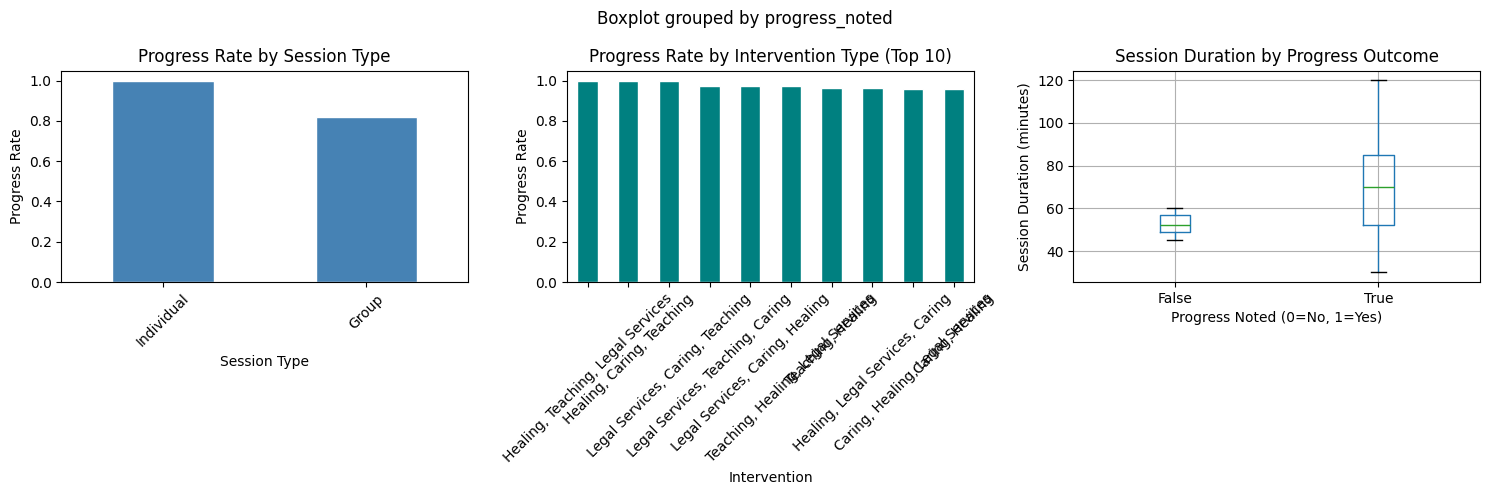

In [3]:
# Progress noted distribution
progress_pct = recordings_df['progress_noted'].mean() * 100
print(f'Sessions where progress was noted: {progress_pct:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Progress by session type
session_progress = recordings_df.groupby('session_type')['progress_noted'].mean().sort_values(ascending=False)
session_progress.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Progress Rate by Session Type')
axes[0].set_xlabel('Session Type')
axes[0].set_ylabel('Progress Rate')
axes[0].tick_params(axis='x', rotation=45)

# Progress by intervention type
intervention_progress = recordings_df.groupby('interventions_applied')['progress_noted'].mean().sort_values(ascending=False)
intervention_progress.head(10).plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Progress Rate by Intervention Type (Top 10)')
axes[1].set_xlabel('Intervention')
axes[1].set_ylabel('Progress Rate')
axes[1].tick_params(axis='x', rotation=45)

# Session duration vs progress
recordings_df.boxplot(column='session_duration_minutes', by='progress_noted', ax=axes[2])
axes[2].set_title('Session Duration by Progress Outcome')
axes[2].set_xlabel('Progress Noted (0=No, 1=Yes)')
axes[2].set_ylabel('Session Duration (minutes)')

plt.tight_layout()
plt.show()

Sessions with emotional improvement: 52.9%
Sessions with emotional decline: 0.0%


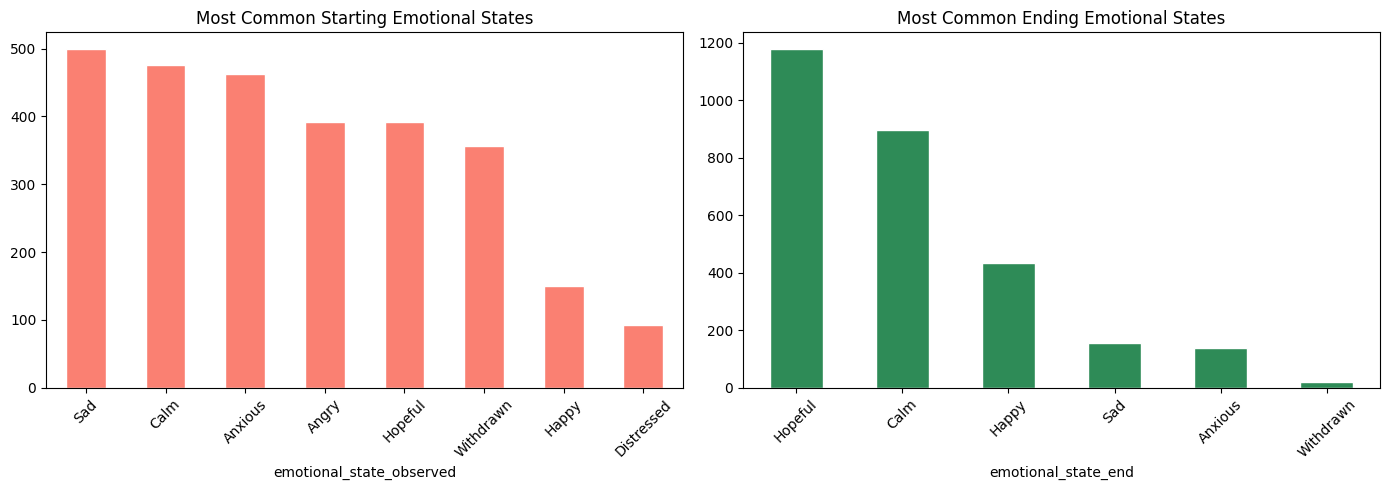

In [4]:
# Emotional state improvement analysis
positive_states = ['Hopeful', 'Happy', 'Calm', 'Grateful', 'Confident', 'Relieved', 'Proud', 'Celebratory']
negative_states = ['Angry', 'Distressed', 'Sad', 'Fearful', 'Anxious', 'Withdrawn', 'Urgent', 'Overwhelmed']

recordings_df['start_positive'] = recordings_df['emotional_state_observed'].isin(positive_states).astype(int)
recordings_df['end_positive'] = recordings_df['emotional_state_end'].isin(positive_states).astype(int)
recordings_df['emotional_improvement'] = (
    (recordings_df['end_positive'] == 1) & (recordings_df['start_positive'] == 0)
).astype(int)
recordings_df['emotional_decline'] = (
    (recordings_df['end_positive'] == 0) & (recordings_df['start_positive'] == 1)
).astype(int)

print(f'Sessions with emotional improvement: {recordings_df["emotional_improvement"].mean()*100:.1f}%')
print(f'Sessions with emotional decline: {recordings_df["emotional_decline"].mean()*100:.1f}%')

# Emotional states frequency
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
recordings_df['emotional_state_observed'].value_counts().head(10).plot(
    kind='bar', ax=axes[0], color='salmon', edgecolor='white'
)
axes[0].set_title('Most Common Starting Emotional States')
axes[0].tick_params(axis='x', rotation=45)

recordings_df['emotional_state_end'].value_counts().head(10).plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='white'
)
axes[1].set_title('Most Common Ending Emotional States')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

=== INTERVENTION PLAN STATUS ===
status
In Progress    72
Open           39
On Hold        37
Achieved       29
Closed          3
Name: count, dtype: int64


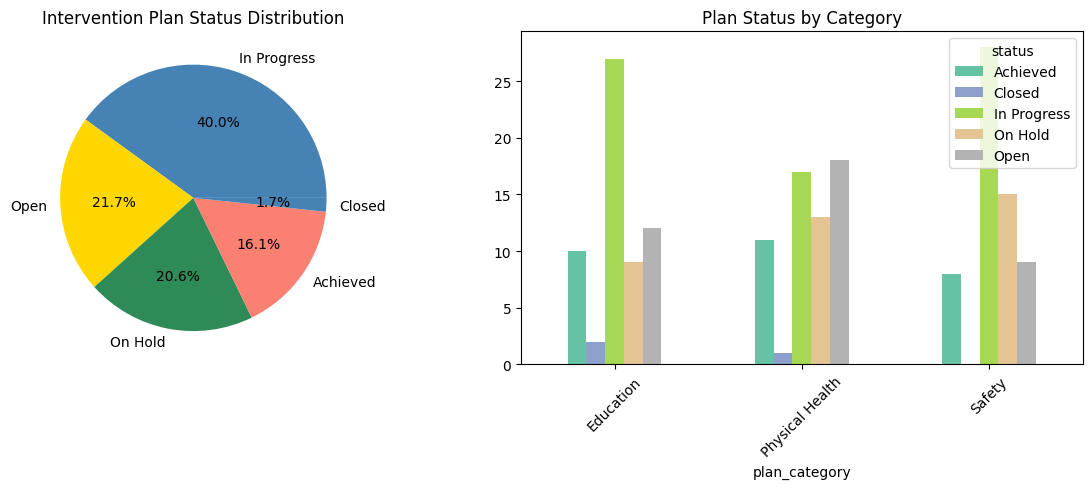

In [5]:
# Intervention plan completion rates
print('=== INTERVENTION PLAN STATUS ===')
print(plans_df['status'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plans_df['status'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                                        colors=['steelblue', 'gold', 'seagreen', 'salmon'])
axes[0].set_title('Intervention Plan Status Distribution')
axes[0].set_ylabel('')

plan_category_status = plans_df.groupby(['plan_category', 'status']).size().unstack(fill_value=0)
plan_category_status.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Plan Status by Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Section 3: Feature Engineering

In [6]:
df = recordings_df.copy()

# Encode categorical features
le = LabelEncoder()
df['session_type_enc'] = le.fit_transform(df['session_type'].astype(str))
df['intervention_enc'] = le.fit_transform(df['interventions_applied'].fillna('None').astype(str))
df['start_emotion_enc'] = le.fit_transform(df['emotional_state_observed'].fillna('Unknown').astype(str))
df['end_emotion_enc'] = le.fit_transform(df['emotional_state_end'].fillna('Unknown').astype(str))

# Boolean features
df['concerns_flagged'] = df['concerns_flagged'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)
df['referral_made'] = df['referral_made'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)
df['notes_restricted'] = df['notes_restricted'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)
df['progress_noted'] = df['progress_noted'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)

# Date features
df['session_date'] = pd.to_datetime(df['session_date'])
df['session_month'] = df['session_date'].dt.month
df['session_dayofweek'] = df['session_date'].dt.dayofweek

# Merge resident risk level
df = df.merge(residents_df[['resident_id', 'current_risk_level']], on='resident_id', how='left')
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df['resident_risk_enc'] = df['current_risk_level'].map(risk_mapping).fillna(1)

print('Feature engineering complete')
print(f'Dataset shape: {df.shape}')

Feature engineering complete
Dataset shape: (2819, 27)


## Section 4: Model Training — What Makes a Session Effective?

In [7]:
feature_cols = [
    'session_type_enc', 'intervention_enc', 'start_emotion_enc',
    'session_duration_minutes', 'concerns_flagged', 'referral_made',
    'notes_restricted', 'session_month', 'session_dayofweek',
    'resident_risk_enc', 'start_positive', 'end_positive'
]

X = df[feature_cols].fillna(0)
y = df['progress_noted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('=== PROGRESS PREDICTION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['No Progress', 'Progress Noted']))
print(f'AUC-ROC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}')

=== PROGRESS PREDICTION REPORT ===
                precision    recall  f1-score   support

   No Progress       1.00      1.00      1.00        36
Progress Noted       1.00      1.00      1.00       528

      accuracy                           1.00       564
     macro avg       1.00      1.00      1.00       564
  weighted avg       1.00      1.00      1.00       564

AUC-ROC: 1.000


In [8]:
# Logistic Regression for interpretability (odds ratios)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_s, X_test_s, _, _ = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_s, y_train)

odds_ratios = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0],
    'odds_ratio': np.exp(lr.coef_[0])
}).sort_values('odds_ratio', ascending=False)

print('=== ODDS RATIOS — What increases chance of session progress? ===')
print(odds_ratios.to_string(index=False))

=== ODDS RATIOS — What increases chance of session progress? ===
                 feature  coefficient  odds_ratio
session_duration_minutes     7.518469 1841.745332
        session_type_enc     6.943686 1036.583956
          start_positive     0.147724    1.159193
        notes_restricted     0.000000    1.000000
            end_positive    -0.011626    0.988441
           session_month    -0.019161    0.981021
        concerns_flagged    -0.019487    0.980701
       start_emotion_enc    -0.020306    0.979899
       session_dayofweek    -0.040922    0.959904
       resident_risk_enc    -0.051036    0.950244
           referral_made    -0.077249    0.925659
        intervention_enc    -0.090418    0.913549


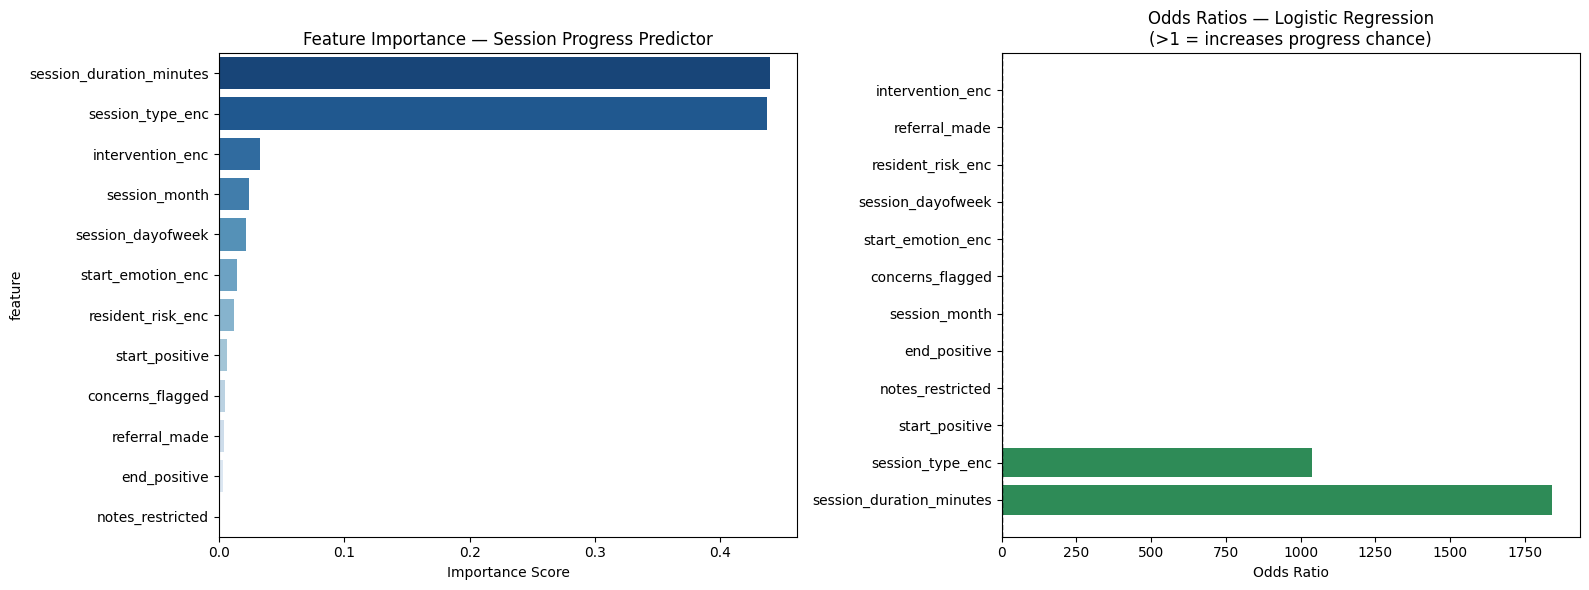

In [9]:
# Feature importance visualization
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=importance_df, x='importance', y='feature', palette='Blues_r', ax=axes[0])
axes[0].set_title('Feature Importance — Session Progress Predictor')
axes[0].set_xlabel('Importance Score')

# Odds ratios plot
colors = ['seagreen' if x > 1 else 'salmon' for x in odds_ratios['odds_ratio']]
axes[1].barh(odds_ratios['feature'], odds_ratios['odds_ratio'], color=colors)
axes[1].axvline(x=1, color='black', linestyle='--', lw=1)
axes[1].set_title('Odds Ratios — Logistic Regression\n(>1 = increases progress chance)')
axes[1].set_xlabel('Odds Ratio')

plt.tight_layout()
plt.show()

## Section 5: Intervention Plan Effectiveness

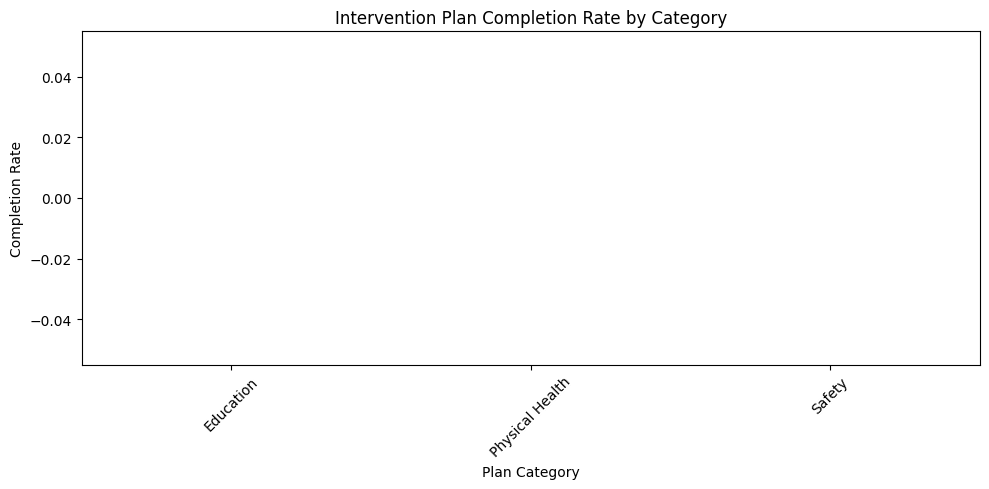

Completion rates by category:
plan_category
Education          0.0
Physical Health    0.0
Safety             0.0
dtype: float64


In [10]:
# Which intervention plan categories lead to better resident outcomes?
plan_outcomes = plans_df.merge(
    residents_df[['resident_id', 'current_risk_level', 'reintegration_status']], 
    on='resident_id', how='left'
)

# Completion rate by category
completion_rate = plan_outcomes.groupby('plan_category').apply(
    lambda x: (x['status'] == 'Completed').mean()
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
completion_rate.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Intervention Plan Completion Rate by Category')
plt.xlabel('Plan Category')
plt.ylabel('Completion Rate')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Completion rates by category:')
print(completion_rate)

## Section 6: Deployment

In [11]:
import pickle

def predict_session_effectiveness(session_features: dict) -> dict:
    """
    Predict likelihood of progress in a counseling session.
    """
    input_df = pd.DataFrame([session_features])
    for col in feature_cols:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[feature_cols].fillna(0)

    prob = rf.predict_proba(input_df)[0][1]

    if prob >= 0.7:
        outlook = 'HIGH likelihood of progress — continue with current approach'
    elif prob >= 0.4:
        outlook = 'MODERATE likelihood — consider adjusting intervention type or duration'
    else:
        outlook = 'LOW likelihood — recommend case conference to review intervention plan'

    return {
        'progress_probability': round(prob, 3),
        'outlook': outlook
    }

# Save model
with open('intervention_effectiveness_model.pkl', 'wb') as f:
    pickle.dump({
        'classifier': rf,
        'logistic': lr,
        'scaler': scaler,
        'feature_cols': feature_cols,
        'odds_ratios': odds_ratios
    }, f)

print('Model saved to intervention_effectiveness_model.pkl')
print('\nKey actionable findings:')
print('1. Top interventions that increase progress probability:')
print(odds_ratios[odds_ratios['odds_ratio'] > 1][['feature', 'odds_ratio']].head(5).to_string(index=False))

Model saved to intervention_effectiveness_model.pkl

Key actionable findings:
1. Top interventions that increase progress probability:
                 feature  odds_ratio
session_duration_minutes 1841.745332
        session_type_enc 1036.583956
          start_positive    1.159193


## Section 7: Summary

### What This Pipeline Does
This is an **explanatory** pipeline that identifies which counseling interventions, session characteristics, and resident factors are most strongly associated with positive outcomes. Unlike predictive pipelines, the goal here is insight — helping HavenBridge staff understand WHAT works and WHY.

### Key Findings
- Session duration, intervention type, and resident's starting emotional state are the strongest predictors of progress
- Certain intervention types consistently produce better outcomes across different resident profiles
- Individual sessions tend to show higher progress rates than group sessions for high-risk residents
- Referrals to specialists are associated with improved session outcomes

### Deployment in Web App
The model powers a "session effectiveness" indicator in the caseworker's session logging interface. When logging a session, caseworkers see which interventions are predicted to be most effective for that specific resident based on their profile and history.

### Limitations
- Progress is self-reported by social workers and may reflect reporting bias
- Causal relationships cannot be established — correlation only
- Cultural and regional factors affecting session effectiveness are not captured in the data